# Model Evaluation & Cross-Validation Strategies

A single train/test split can be misleading: depending on the random seed, your test set might accidentally get the easiest or hardest samples.

Cross-Validation (CV) splits your training data into $K$ distinct folds, repeatedly training on $K-1$ folds and validating on the remaining fold. This provides a reliable estimate of model performance with a mean score and standard deviation.

### In this notebook, we compare 4 Core CV Splitters:
1. **Standard K-Fold (`KFold`)**: For balanced, independent, uniformly distributed tabular data.
2. **Stratified K-Fold (`StratifiedKFold`)**: Essential for classification tasks to preserve class proportions across every fold.
3. **Time Series Split (`TimeSeriesSplit`)**: Forward-chaining validation for temporal data (preventing future-to-past leakage).
4. **Group K-Fold (`GroupKFold`)**: For grouped/clustered data (e.g., multiple rows per patient or customer) where a single entity must never appear in both train and test splits.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    TimeSeriesSplit,
    GroupKFold,
    cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

np.random.seed(42)

# Helper function to visualize split boundaries across folds
def plot_cv_indices(cv_splitter, X, y=None, groups=None, title="Cross-Validation Split"):
    """Visualizes the train/validation splits across iterations."""
    fig, ax = plt.subplots(figsize=(9, 4))
    
    n_splits = cv_splitter.get_n_splits(X, y, groups)
    
    for i, (train_idx, val_idx) in enumerate(cv_splitter.split(X, y, groups)):
        indices = np.array([np.nan] * len(X))
        indices[train_idx] = 1   # Training set
        indices[val_idx] = 0     # Validation set
        
        ax.scatter(
            range(len(indices)), 
            [i + 0.5] * len(indices), 
            c=indices, 
            cmap=plt.cm.coolwarm, 
            marker='|', 
            lw=8,
            vmin=0, 
            vmax=1
        )

    ax.set_yticks([x + 0.5 for x in range(n_splits)])
    ax.set_yticklabels([f"Fold {x+1}" for x in range(n_splits)])
    ax.set_ylabel("CV Fold")
    ax.set_xlabel("Sample Index")
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.2, n_splits)
    ax.set_xlim(-1, len(X))
    
    # Custom legend: Red = Train, Blue = Validation
    handles = [
        plt.Line2D([0], [0], color='#b40426', lw=4, label='Train Fold'),
        plt.Line2D([0], [0], color='#3b4cc0', lw=4, label='Validation Fold')
    ]
    ax.legend(handles=handles, loc='upper right')
    plt.tight_layout()
    plt.show()

print("Helper visualization functions defined.")

Helper visualization functions defined.


---
## Strategy 1: K-Fold vs. Stratified K-Fold (The Imbalance Trap)

* **Standard `KFold`**: Splits data purely randomly into $K$ partitions. If your target is skewed (e.g., 90% No-Churn, 10% Churn), some folds may randomly receive very few or zero positive targets.
* **`StratifiedKFold`**: Enforces that **every single fold** contains the exact same percentage of target classes as the complete dataset.

=== CHECKING TARGET PROPORTIONS PER FOLD ===
Standard K-Fold class 1 ratios per fold:
  Fold 1: 5.0% positive samples
  Fold 2: 10.0% positive samples
  Fold 3: 5.0% positive samples
  Fold 4: 20.0% positive samples
  Fold 5: 10.0% positive samples

Stratified K-Fold class 1 ratios per fold:
  Fold 1: 10.0% positive samples
  Fold 2: 10.0% positive samples
  Fold 3: 10.0% positive samples
  Fold 4: 10.0% positive samples
  Fold 5: 10.0% positive samples


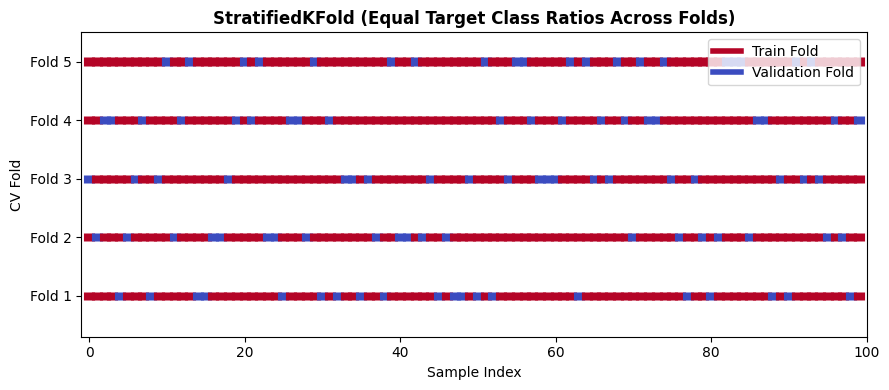

In [4]:
# Generate skewed classification data (90% class 0, 10% class 1)
n_samples = 100
X_dummy = np.random.randn(n_samples, 2)
y_imbalanced = np.array([0] * 90 + [1] * 10)  # Skewed class distribution

# 1. Standard KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Stratified KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== CHECKING TARGET PROPORTIONS PER FOLD ===")
print("Standard K-Fold class 1 ratios per fold:")
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_dummy, y_imbalanced)):
    val_ratio = y_imbalanced[val_idx].mean()
    print(f"  Fold {fold_idx+1}: {val_ratio:.1%} positive samples")

print("\nStratified K-Fold class 1 ratios per fold:")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_dummy, y_imbalanced)):
    val_ratio = y_imbalanced[val_idx].mean()
    print(f"  Fold {fold_idx+1}: {val_ratio:.1%} positive samples")

# Visualizing Stratified K-Fold
plot_cv_indices(skf, X_dummy, y_imbalanced, title="StratifiedKFold (Equal Target Class Ratios Across Folds)")

---
## Strategy 2: Time Series Split (`TimeSeriesSplit`)

### Why Standard CV Fails on Temporal Data:
In standard CV, samples are shuffled across the entire timeline. A model could train on data from December to predict events in February, which violates the arrow of time (**Lookahead / Future Leakage**).

**`TimeSeriesSplit` (Rolling Window / Forward Chaining):**
* Fold 1: Train on month 1 $\rightarrow$ Validate on month 2
* Fold 2: Train on months 1–2 $\rightarrow$ Validate on month 3
* Fold 3: Train on months 1–3 $\rightarrow$ Validate on month 4
The training set strictly precedes the validation set in time.

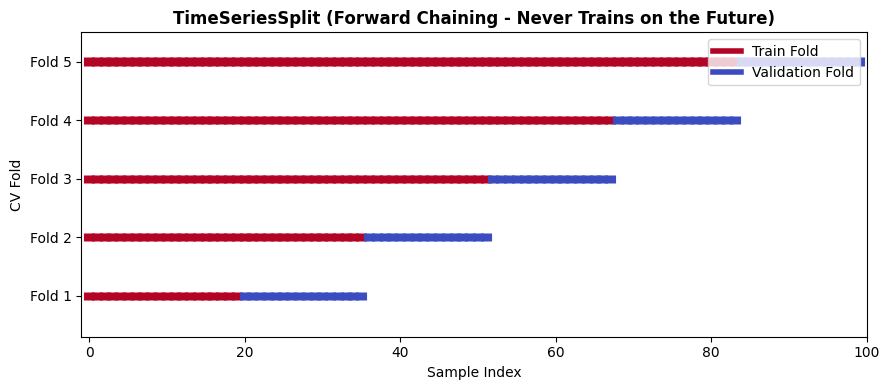

In [5]:
# Simulating temporal data (ordered by date/time)
n_time_steps = 100
X_time = np.random.randn(n_time_steps, 2)
y_time = np.random.randint(0, 2, size=n_time_steps)

tscv = TimeSeriesSplit(n_splits=5)

# Visualizing Time Series Splits
plot_cv_indices(tscv, X_time, y_time, title="TimeSeriesSplit (Forward Chaining - Never Trains on the Future)")

---
## Strategy 3: Group K-Fold (`GroupKFold`)

### The Clustered Data Trap:
Imagine you are predicting customer churn or medical diagnoses:
* If customer `#42` has 10 transaction records in your dataset, standard CV might place 8 of their transactions in the training set and 2 in the validation set.
* The model can memorize that specific customer's habits, showing artificially high validation scores that crash when applied to a completely new customer.

**`GroupKFold`** guarantees that **all rows belonging to a specific group (e.g., patient, customer, device ID) stay together in the same fold**. A group present in the training fold will never appear in the validation fold.

=== GROUP K-FOLD INTEGRITY CHECK ===
Fold 1 Customer Overlap: set() (Should always be empty set)
Fold 2 Customer Overlap: set() (Should always be empty set)
Fold 3 Customer Overlap: set() (Should always be empty set)
Fold 4 Customer Overlap: set() (Should always be empty set)
Fold 5 Customer Overlap: set() (Should always be empty set)


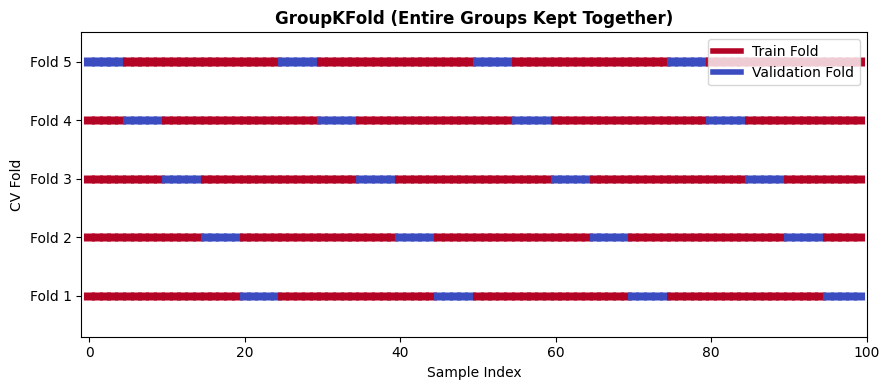

In [6]:
# Simulating grouped customer data: 20 unique customers with 5 rows each (100 total rows)
n_records = 100
customer_groups = np.repeat(np.arange(1, 21), 5)  # Customer IDs 1 through 20

X_grouped = np.random.randn(n_records, 2)
y_grouped = np.random.randint(0, 2, size=n_records)

gkf = GroupKFold(n_splits=5)

print("=== GROUP K-FOLD INTEGRITY CHECK ===")
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_grouped, y_grouped, groups=customer_groups)):
    train_customers = set(customer_groups[train_idx])
    val_customers = set(customer_groups[val_idx])
    overlap = train_customers.intersection(val_customers)
    print(f"Fold {fold_idx+1} Customer Overlap: {overlap} (Should always be empty set)")

# Visualizing GroupKFold
plot_cv_indices(gkf, X_grouped, y_grouped, groups=customer_groups, title="GroupKFold (Entire Groups Kept Together)")

---
## Summary: Choosing the Right Validation Scheme

| Scenario / Data Type | Recommended CV Strategy | Why? |
| :--- | :--- | :--- |
| **Standard Tabular (Classification)** | `StratifiedKFold` | Preserves the minority class percentage in every fold. |
| **Standard Tabular (Regression)** | `KFold(shuffle=True)` | Randomizes samples across splits. |
| **Time Series / Stock / Sequential** | `TimeSeriesSplit` | Prevents future data leakage into the past. |
| **Multi-Row Entities (Users, Devices, Patients)** | `GroupKFold` | Tests generalization to completely unseen entities. |

# What these code cells in this notebook actually represent:

Strip away all the code for a moment.

At its core, this notebook answers one single question: **"How do you fairly test your model so you aren't fooling yourself?"**

When you build a model, you never evaluate it on the data it memorized during training. You always hide a piece of data (the "Validation Set") to test whether the model actually learned patterns.

This notebook teaches you that **a simple random split can completely lie to you**, and shows you the **4 proper ways to split data** depending on the problem.

---

### The 4 Real-World Scenarios (What to Focus On)

#### 1. The Normal Case: `KFold`

* **The Idea:** Don't just test your model once. Split your training data into 5 equal slices (folds). Train on 4, test on 1. Repeat this 5 times so every single row gets tested once.
* **When to use:** Standard, simple datasets where rows are independent and targets are balanced.

---

#### 2. The Imbalanced Case: `StratifiedKFold`

* **The Problem:** Suppose you are detecting credit card fraud where only $2\%$ of transactions are fraud. If you randomly chop the data into 5 slices, one slice might accidentally get **zero fraud cases**. Testing on that slice is completely useless.
* **The Fix:** `StratifiedKFold` forces every slice to have the exact same $2\%$ fraud rate.
* **Rule of thumb:** Always use this for classification tasks.

---

#### 3. The Time-Travel Trap: `TimeSeriesSplit`

* **The Problem:** You have stock prices or sales data from January to December. If you randomly shuffle rows, your model will use data from **December** to predict what happened in **March**. That is looking into the future—cheating that will fail in real life.
* **The Fix:** It forces forward-only training:
* Train on Jan $\rightarrow$ Test on Feb.
* Train on Jan–Feb $\rightarrow$ Test on Mar.
* Train on Jan–Mar $\rightarrow$ Test on Apr.


* **Rule of thumb:** Always use this if your data has dates or timestamps.

---

#### 4. The Customer/Patient Leak: `GroupKFold`

* **The Problem:** Imagine you have a medical dataset. Patient John has 10 X-rays. If 8 of John's X-rays are in the training set and 2 are in the test set, the model doesn't learn how to spot disease—it just memorizes what John's ribs look like. When a brand-new patient walks in, the model fails.
* **The Fix:** `GroupKFold` ensures that **all 10 of John's X-rays stay together in one slice**. John is either entirely in the training data or entirely in the test data, never split between both.
* **Rule of thumb:** Always use this if you have multiple rows belonging to the same person, device, or user ID.

---

### Why Did the Code Look So Complicated?

most of the cells contained a custom Matplotlib plotting function (`plot_cv_indices`). **That was purely to draw the colorful diagram.**

You do not need to memorize or write that custom plotting code in your daily work.

In real projects, you only use **2 lines**:

```python
# 1. Choose your splitting strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Let Scikit-Learn handle all 5 training/testing loops automatically!
scores = cross_val_score(your_model, X_train, y_train, cv=cv, scoring='roc_auc')
print("Average Score:", scores.mean())

```

Focus solely on matching the data scenario to the right splitter name from the table at the end of the notebook.

# Here is some information about the difference between validation and test sets in cross-validation.
You still need `train_test_split`. Cross-validation does not replace it; they work together in a hierarchy.

```text
Full Dataset
 ├── Train Set (80%)  ──► Handled by Cross-Validation (Train Folds vs. Validation Folds)
 └── Test Set  (20%)  ──► Locked in a vault until the very end

```

---

### Why Not Just Use Cross-Validation Directly on Everything?

If you skip `train_test_split` and run cross-validation on your entire dataset, you lose your final, unbiased check against reality.

When you test 20 different models, feature sets, or hyperparameters using cross-validation scores to pick the winner, you are subtly tuning your choices to please those validation folds.

The **Test Set** acts as an uncorrupted audit: data that had zero influence on model selection, tuning, or threshold decisions.

---

### Why Do We Need Both a Validation Set and a Test Set?

Think of machine learning like a student preparing for a final exam:

**Training Set (The Practice Problems):**
* The student studies these problems with the answers in the back of the book.
* The model adjusts its internal weights and learns patterns here.


**Validation Set (The Mock Exams / Quizzes):**
* The teacher gives the student practice tests to check how well they are retaining the material.
* If the student scores poorly on the mock exam, they adjust their study habits (in ML: you tweak hyperparameters, select different features, or try a different algorithm).
* Because you use mock exam scores to adjust the model, the model indirectly "sees" this data through your decisions.


**Test Set (The Final Board Exam):**
* Taken once at the very end of the year.
* Neither the student nor the teacher gets to change anything after seeing the questions.
* This score represents the true ability to generalize to brand-new, unseen data in production.

---

### The Standard Workflow

1. **`train_test_split`** splits off 20% into `X_test, y_test` and locks it away.
2. Inside `X_train, y_train`, **Cross-Validation** creates the internal train/validation splits to compare models and tune hyperparameters.
3. Once the best configuration is chosen and trained on `X_train`, you score it once on `X_test` to confirm its real-world performance.

---

#### In simple. The core purpose of validation set is mostly hyperparameter tuning and technique changes.

You have parameters that the model **learns automatically** from data (like linear regression weights or decision tree split points), and **hyperparameters** that you must choose ahead of time:

**Preprocessing Knobs:**
* Imputation strategy: `'mean'` vs. `'median'`
* Scaling type: `StandardScaler` vs. `RobustScaler`
* Feature selection threshold: correlation $> 0.80$ vs. $> 0.90$, or top $k = 5$ vs. $k = 10$


**Model Knobs:**
* Random Forest: `n_estimators = 100` vs. `300`, `max_depth = 5` vs. `15`
* Logistic Regression / Lasso: `C = 0.01` vs. `1.0` vs. `10.0`
* Gradient Boosting: `learning_rate = 0.01` vs. `0.1`



Instead of manually guessing and running the code 50 times by hand, tools like **`GridSearchCV`** and **`RandomizedSearchCV`** take a list or dictionary of those knobs, run all combinations automatically inside your cross-validation folds, and hand you the best-performing pipeline configuration.

# Breakdown of code cells listed above:

while the code cells may Actually complex here, But they are very simpler to actually implement, and the reason why they look complex is because the code cells are actually also visualizing you how the folds are actually getting there. And the reality is you **choose one specific technique for cross validation technique** and simply use this **cross_val_score** function to see how that specific CV technique is working. simple!. 

> Note: The next code cell is full code through which you'll understand in which code line changes can trigger the code to use different techniques and some other things.

One main doubt you might get here is:
#### How and where is the validation set splitting is happening?
The split ratio is controlled directly by the **`n_splits`** parameter.

* **The Formula:** In any $K$-Fold cross-validation, the validation size for each fold is always:

$$\text{Validation Ratio} = \frac{1}{K} = \frac{1}{\text{n\_splits}}$$


* **Default Ratio:** Scikit-Learn defaults to `n_splits=5`, which automatically makes the split **80% Training and 20% Validation** on every iteration ($1/5 = 0.20$).
* **Can You Change It?** Yes, by simply altering `n_splits`:
* `n_splits=10` $\rightarrow$ **90% Train / 10% Validation** ($1/10 = 0.10$)
* `n_splits=4` $\rightarrow$ **75% Train / 25% Validation** ($1/4 = 0.25$)
* `n_splits=3` $\rightarrow$ **66.7% Train / 33.3% Validation** ($1/3 \approx 0.33$)

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# 1. Create sample tabular data (1,000 rows, binary classification)
X_raw, y_raw = make_classification(n_samples=1000, n_features=10, random_state=42)
X = pd.DataFrame(X_raw, columns=[f"feat_{i}" for i in range(10)])
y = pd.Series(y_raw, name="target")

# 2. Split once into Train (80%) and Test (20%)
# The 20% test set is locked away for final audit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Define the Cross-Validation strategy and the model
# StratifiedKFold dynamically cuts X_train into internal Train/Validation folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = HistGradientBoostingClassifier(random_state=42)

# 4. Evaluate across internal validation folds using cross_val_score
# It runs 5 times: trains on 4 folds, validates on the 5th fold
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

print("=== CROSS-VALIDATION RESULTS (INTERNAL VALIDATION SETS) ===")
print(f"5-Fold ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"Mean Validation ROC-AUC: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# 5. Train on the complete training set and test once on the unseen Test Set
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== FINAL TEST SET PERFORMANCE (THE LOCKED AUDIT) ===")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred))

=== CROSS-VALIDATION RESULTS (INTERNAL VALIDATION SETS) ===
5-Fold ROC-AUC Scores: [0.9714 0.9694 0.9664 0.9781 0.9736]
Mean Validation ROC-AUC: 0.9718 (± 0.0040)

=== FINAL TEST SET PERFORMANCE (THE LOCKED AUDIT) ===
Test ROC-AUC: 0.9585
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       100
           1       0.95      0.84      0.89       100

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.90      0.90       200



## How to Swap Strategies
To change the validation strategy, you only change the cv definition:

### 1. Standard K-Fold (Regression/Balanced data):

```python
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
```

### 2. Time Series (Stock/Sensor/Dates):

```python 
cv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
```

### 3. Group K-Fold (Customers/Patients):
Pass groups=customer_ids directly into cross_val_score:

```python 
cv = GroupKFold(n_splits=5)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, groups=train_groups, scoring='roc_auc')
```
#### Why `groups` is only for `GroupKFold`
Standard splitters only need row counts or class labels to split data, but `GroupKFold` has no way of knowing which rows belong to the same person, device, or store unless you explicitly hand it that ID array via `groups=...`. Without it, it cannot keep an entity's rows together.

#### Why `customer_ids` vs. `train_groups`
They refer to the exact same concept—it was just inconsistent variable naming:

* `customer_ids` represents the conceptual column in your raw data (e.g., `df['customer_id']`).
* Because `cross_val_score` is evaluated strictly on the training portion, you pass the training slice of those IDs:

```python
groups = train_groups  # or groups=X_train['customer_id']
```
> Note: `groups` parameter is strictly used for group-based splitters (like GroupKFold or StratifiedGroupKFold) because only they need an identifier to keep related rows together. Standard splitters like KFold, StratifiedKFold, and TimeSeriesSplit do not use it.